<a href="https://colab.research.google.com/github/Gokul302005/Digital_portfolio/blob/main/Final_year_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the number of classes attended by each student (0 to 22):

Gokul S (FYP001): 22
Arjun K (FYP002): 20
Priya R (FYP003): 1
Divya S (FYP004): 21
Rahul M (FYP005): 0
Sneha P (FYP006): 22
Karthik V (FYP007): 18
Anjali T (FYP008): 15
Vishnu H (FYP009): 12
Meena R (FYP010): 20

Attendance report with exam rules generated successfully!

  Student ID Student Name  Total Classes  Classes Attended  Classes Missed  \
0     FYP001      Gokul S             22                22               0   
1     FYP002      Arjun K             22                20               2   
2     FYP003      Priya R             22                 1              21   
3     FYP004      Divya S             22                21               1   
4     FYP005      Rahul M             22                 0              22   
5     FYP006      Sneha P             22                22               0   
6     FYP007    Karthik V             22                18               4   
7     FYP008     Anjali T             2

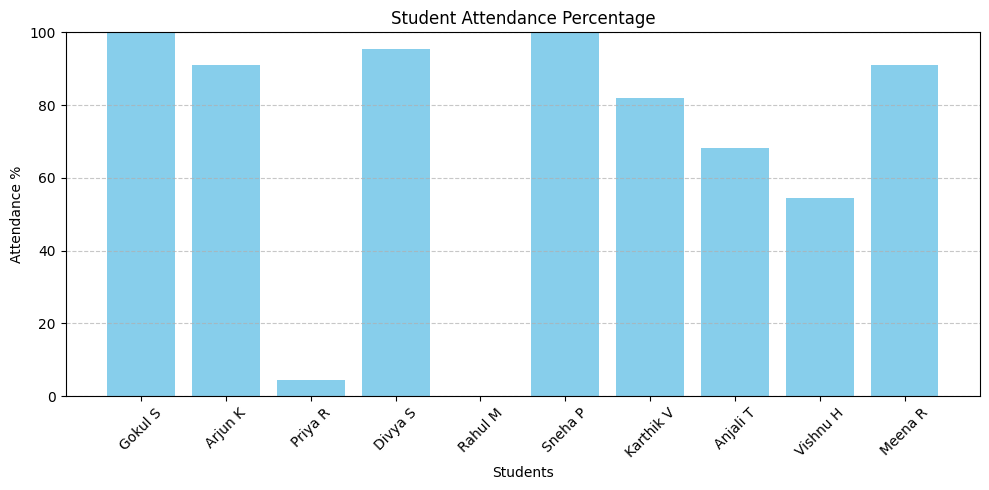

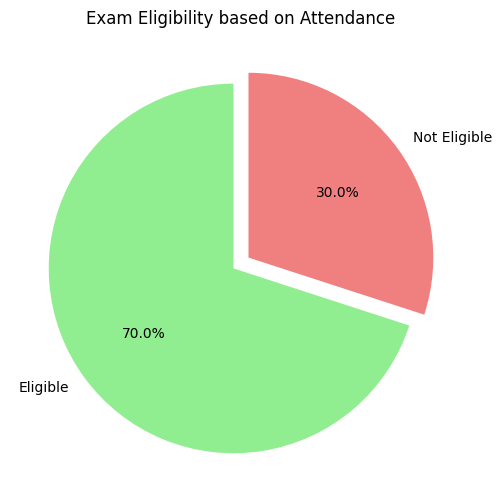

In [3]:
# ========================================
# Automated Attendance Management System
# ========================================

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create student data
students = [
    {"Student ID": "FYP001", "Student Name": "Gokul S"},
    {"Student ID": "FYP002", "Student Name": "Arjun K"},
    {"Student ID": "FYP003", "Student Name": "Priya R"},
    {"Student ID": "FYP004", "Student Name": "Divya S"},
    {"Student ID": "FYP005", "Student Name": "Rahul M"},
    {"Student ID": "FYP006", "Student Name": "Sneha P"},
    {"Student ID": "FYP007", "Student Name": "Karthik V"},
    {"Student ID": "FYP008", "Student Name": "Anjali T"},
    {"Student ID": "FYP009", "Student Name": "Vishnu H"},
    {"Student ID": "FYP010", "Student Name": "Meena R"},
]

# Step 2: Convert to DataFrame
df = pd.DataFrame(students)

# Step 3: Get user input for attendance
total_classes = 22
attendance_data = []

print("Enter the number of classes attended by each student (0 to 22):\n")

for student in students:
    while True:
        try:
            classes_attended = int(input(f"{student['Student Name']} ({student['Student ID']}): "))
            if 0 <= classes_attended <= total_classes:
                break
            else:
                print(f"Please enter a value between 0 and {total_classes}.")
        except ValueError:
            print("Invalid input! Enter an integer value.")

    classes_missed = total_classes - classes_attended
    attendance_percent = round((classes_attended / total_classes) * 100, 2)

    # Step 4: Determine exam eligibility and fine
    if attendance_percent < 65:
        exam_status = "Not Allowed"
        fine = 500
    else:
        exam_status = "Allowed"
        fine = 0

    attendance_data.append({
        "Total Classes": total_classes,
        "Classes Attended": classes_attended,
        "Classes Missed": classes_missed,
        "Attendance %": attendance_percent,
        "Exam Status": exam_status,
        "Fine (₹)": fine
    })

# Step 5: Combine student info with attendance
attendance_df = pd.DataFrame(attendance_data)
final_report = pd.concat([df, attendance_df], axis=1)

# Step 6: Save to Excel
final_report.to_excel("Student_Attendance_Report_With_Exam_Status.xlsx", index=False)

print("\nAttendance report with exam rules generated successfully!\n")
print(final_report)

# ========================================
# Step 7: Visualization - Two Charts Only
# ========================================

# BAR CHART: Attendance % of each student
plt.figure(figsize=(10,5))
plt.bar(final_report["Student Name"], final_report["Attendance %"], color='skyblue')
plt.title("Student Attendance Percentage")
plt.xlabel("Students")
plt.ylabel("Attendance %")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# PIE CHART: Exam Eligibility
eligible = len(final_report[final_report["Exam Status"] == "Allowed"])
not_eligible = len(final_report[final_report["Exam Status"] == "Not Allowed"])

labels = ["Eligible", "Not Eligible"]
sizes = [eligible, not_eligible]
colors = ['lightgreen', 'lightcoral']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05,0.05))
plt.title("Exam Eligibility based on Attendance")
plt.show()222